In [2]:
%load_ext autoreload
%autoreload 2

### Global Variables
DATA_SAVE_PATH = "../../../models/used_data"
DAYS_PER_EPISODE = 3
TRAIN_TEST_SPLIT_FRACTION = 0.2  # Amount of data you reserve for testing.
BUFFER_DAYS = 3  # Amount of days that needs to be between the test episodes.

In [3]:
from Simulation.suite_simple_trading.pre_processing import clean_data
import pandas as pd
import os
from Simulation.suite_simple_trading.data_splitting import get_or_create_train_test_split

### Getting data

raw_data_path = '../../../data/2025_minute.csv'
cleaned_data_cache_path = '../../../data/2025_minute_cleaned.pkl'

if os.path.exists(cleaned_data_cache_path):
    print(f"Loading cached cleaned data from: {cleaned_data_cache_path}")
    cleaned_df = pd.read_pickle(cleaned_data_cache_path)
else:
    print("No cached data found. Running the full cleaning process...")
    raw_df = pd.read_csv(raw_data_path, sep=';')
    cleaned_df = clean_data(raw_df)
    print(f"Saving cleaned data to cache: {cleaned_data_cache_path}")
    cleaned_df.to_pickle(cleaned_data_cache_path)

all_data = cleaned_df[['Datetime', 'Imbalance Price']]
train_df, test_df, nr_of_episodes = get_or_create_train_test_split(
    all_data=all_data,
    save_path=DATA_SAVE_PATH,
    days_per_episode=DAYS_PER_EPISODE,
    test_fraction=TRAIN_TEST_SPLIT_FRACTION,
    buffer_days=BUFFER_DAYS
)

Loading cached cleaned data from: ../../../data/2025_minute_cleaned.pkl
--- Loading existing train/test data from '../../../models/used_data' ---
--- Data loaded successfully. Found 19 test episodes. ---
Test Data Size / Train Data Size: 0.25


In [4]:
from sb3_contrib.common.maskable.policies import MaskableActorCriticPolicy
from sb3_contrib import MaskablePPO
from Simulation.suite_simple_trading.observation_wrappers import RobustScalingWrapper
### The model (Environment) used in all agents

from Simulation.suite_simple_trading.model import TimeAwareBatteryEnv, ExtendedBatteryEnv

train_env = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs = RobustScalingWrapper(train_env)
ppo_agent = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs)
ppo_agent.learn(total_timesteps=200_000, progress_bar=True)


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


Output()

In [5]:
train_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)
train_env_scaled_obs_compare = RobustScalingWrapper(train_env_compare)
ppo_agent_compare = MaskablePPO(MaskableActorCriticPolicy, train_env_scaled_obs_compare)
ppo_agent_compare.learn(total_timesteps=100_000, progress_bar=True)


Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [6]:
from Simulation.suite_simple_trading.policy import PPOAgentDecisionMaker
from Simulation.suite_simple_trading.simulation import run_evaluation

### Testing
test_env = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled = RobustScalingWrapper(test_env)
decision_maker_PPO = PPOAgentDecisionMaker(ppo_agent, test_env_scaled)

result_ppo = run_evaluation(test_env_scaled,
                            ppo_agent, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo["real_rewards"])}")
result_ppo.pop("episodic_rewards")
history_df = pd.DataFrame(result_ppo)
history_df['Datetime'] = test_df['Datetime']


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 9015.84
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 1496.73
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 7449.99
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 2431.63
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 1175.90
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 6708.81
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total 

In [7]:
from Simulation.suite_simple_trading.metrics import print_agent_performance

print_agent_performance(history_df, "PPO Agent with time aware features")

  PERFORMANCE REPORT: PPO Agent with time aware features
  Pos. Profit Quarters : 130
  Neg. Profit Quarters : 73
----------------------------------------
  Success Rate (Active): 64.04%
  Mean Reward / active Quarter: €51.4528
----------------------------------------
  'Trap' Quarters      : 10
  (Started good -> Ended bad)



In [8]:
### Testing
test_env_compare = ExtendedBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled_compare = RobustScalingWrapper(test_env_compare)

result_ppo_compare = run_evaluation(test_env_scaled_compare,
                            ppo_agent_compare, number_of_episodes=nr_of_episodes)
print(f"reward ppo: {sum(result_ppo_compare["real_rewards"])}")
result_ppo_compare.pop("episodic_rewards")
history_df_compare = pd.DataFrame(result_ppo_compare)
history_df_compare['Datetime'] = test_df['Datetime']


--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 8807.66
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 1182.22
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 6030.24
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 2129.34
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 1005.44
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 7715.63
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total 

In [9]:
print_agent_performance(history_df_compare, "PPO Agent Without, to compare")


  PERFORMANCE REPORT: PPO Agent Without, to compare
  Pos. Profit Quarters : 118
  Neg. Profit Quarters : 52
----------------------------------------
  Success Rate (Active): 69.41%
  Mean Reward / active Quarter: €58.4578
----------------------------------------
  'Trap' Quarters      : 9
  (Started good -> Ended bad)



Saving plot to: plots/test_scaling_reward


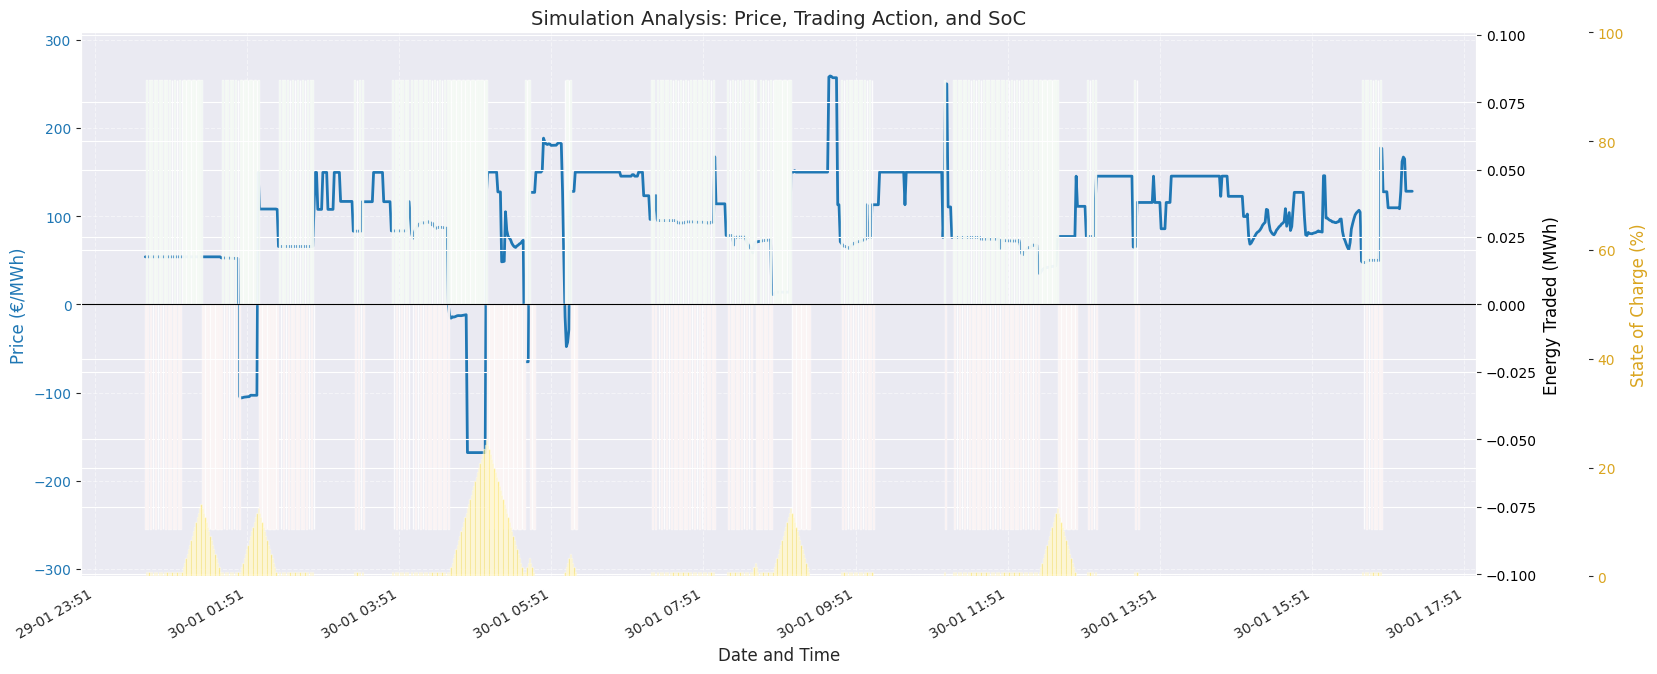

In [10]:
from Simulation.suite_simple_trading.plotting import plot_simulation_results_minute_by_minute, plot_feature_importance

plot_simulation_results_minute_by_minute(
    history_df,
    "test_scaling_reward",
    10_000,
    11_000
)

Saving plot to: plots/test_scaling_reward


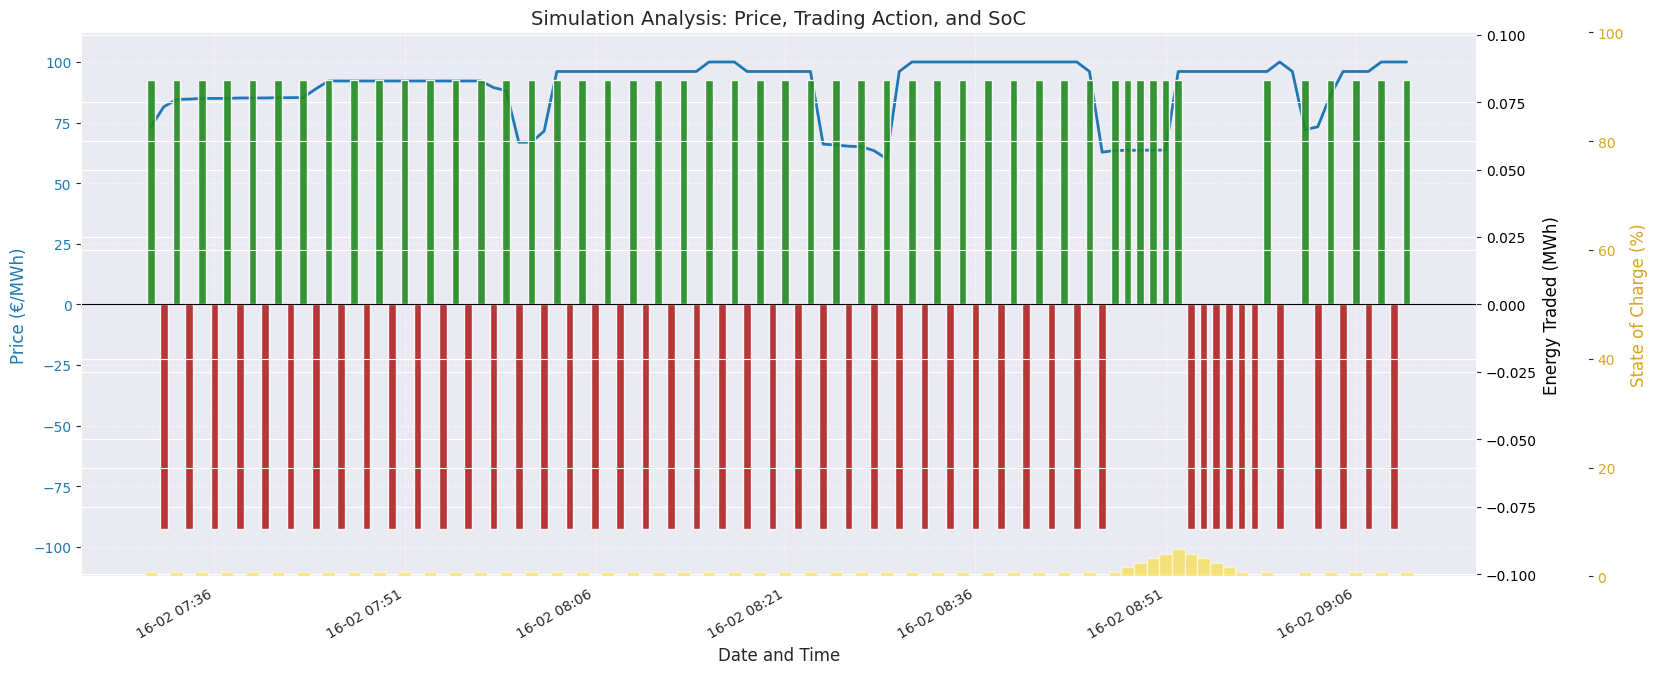

In [11]:
plot_simulation_results_minute_by_minute(
    history_df,
    "test_scaling_reward",
    20_500,
    20_600
)

Maybe it sees in the same quarter that it can get a reward by discharging on the positive price. But eventually it will lead to a 0 reward.

Or it thinks that it made a bad decision and tries to revert its decision.

Saving plot to: plots/iets


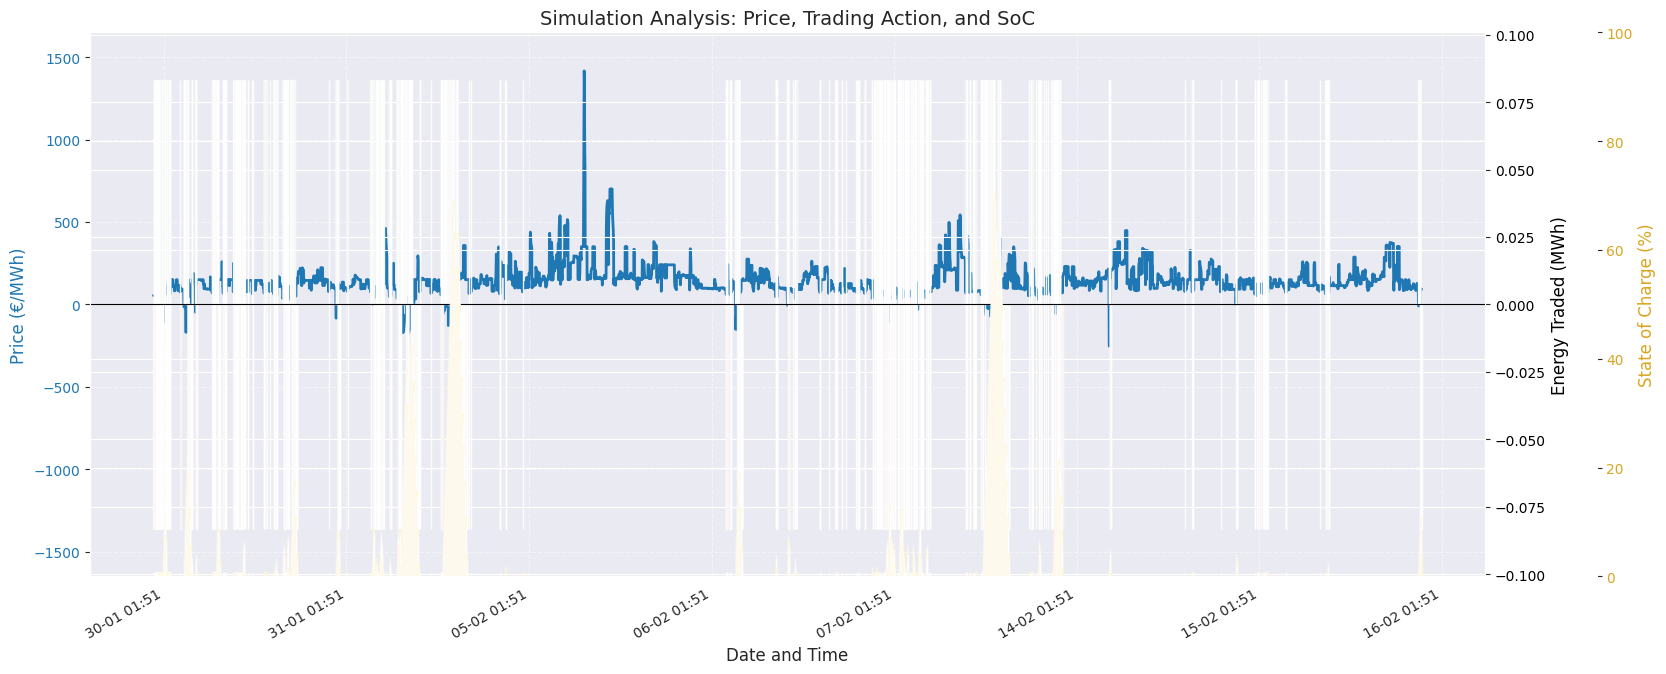

In [12]:
from Simulation.suite_simple_trading.plotting import plot_total_charged_discharged_in_quarter_per_price

plot_simulation_results_minute_by_minute(history_df_compare,
                                                   "iets",
                                                   10_000,
                                                   20_000)

Detected PPO/Actor-Critic architecture.


/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:328: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_names, y=feature_importance, palette='viridis')


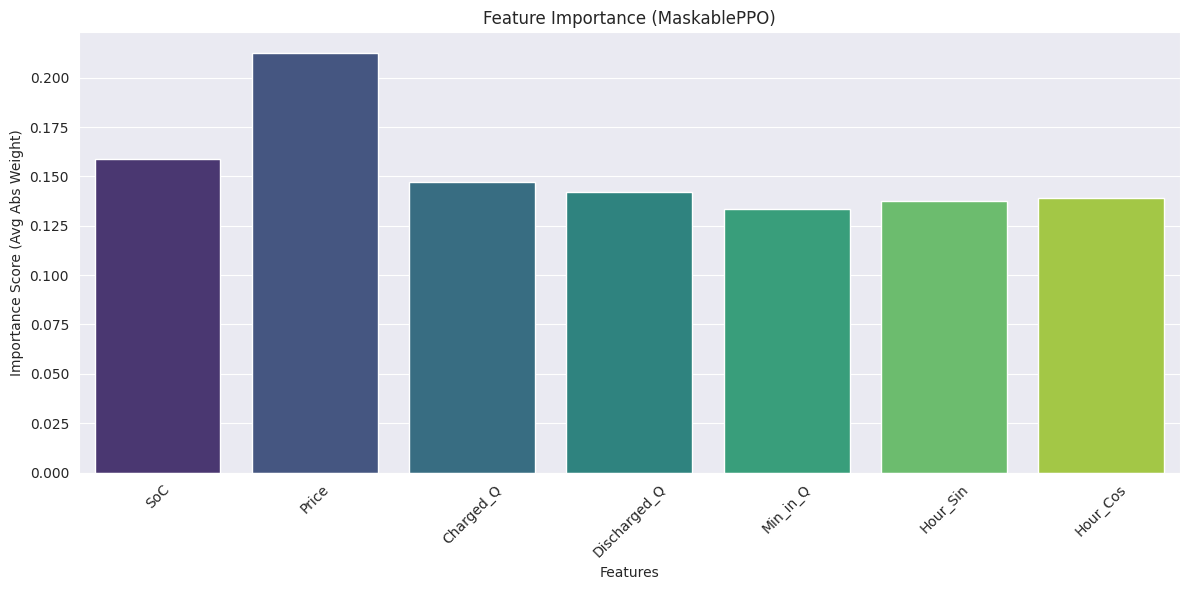

In [13]:
from Simulation.suite_simple_trading.plotting import plot_feature_importance

feature_names = [
    "SoC",
    "Price",
    "Charged_Q",
    "Discharged_Q",
    "Min_in_Q",
    "Hour_Sin", "Hour_Cos",
]
plot_feature_importance(ppo_agent, feature_names)

In [14]:

from stable_baselines3 import DQN

# 1. Create Training Environment
train_env_dqn = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=train_df,
    days_per_episode=DAYS_PER_EPISODE
)

# 2. Apply Scaling
train_env_scaled_dqn = RobustScalingWrapper(train_env_dqn)

# 3. Initialize DQN Agent (Standard, not Maskable)
dqn_agent_compare = DQN("MlpPolicy", train_env_scaled_dqn)

# 4. Train
dqn_agent_compare.learn(total_timesteps=500_000, progress_bar=True)

Output()

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.17, IQR=87.78
--- Wrapper ready. ---


In [15]:
### Testing
test_env_dqn = TimeAwareBatteryEnv(
    battery_capacity_mwh=10.0,
    charge_discharge_rate_mw=5.0,
    all_data=test_df,
    days_per_episode=DAYS_PER_EPISODE
)
test_env_scaled_dqn = RobustScalingWrapper(test_env_dqn)

# Run Evaluation
result_dqn_compare = run_evaluation(test_env_scaled_dqn,
                            dqn_agent_compare, is_masked=False, number_of_episodes=nr_of_episodes)

print(f"reward dqn: {sum(result_dqn_compare['real_rewards'])}")

# Prepare Dataframe for plotting
if "episodic_rewards" in result_dqn_compare:
    result_dqn_compare.pop("episodic_rewards")

history_df_dqn = pd.DataFrame(result_dqn_compare)
# Reset index to ensure alignment with the simulation results
history_df_dqn['Datetime'] = test_df['Datetime'].reset_index(drop=True)

--- Initializing Robust Observation Scaling Wrapper (Method: robust) ---
Price (Robust): Median=78.92, IQR=91.47
--- Wrapper ready. ---
Starting episode 1/19
From 2025-01-03 00:00:00+00:00 to 2025-01-05 23:59:00+00:00
Finished with total (scaled) reward: 7020.02
Starting episode 2/19
From 2025-01-16 00:00:00+00:00 to 2025-01-18 23:59:00+00:00
Finished with total (scaled) reward: 910.95
Starting episode 3/19
From 2025-01-29 00:00:00+00:00 to 2025-01-31 23:59:00+00:00
Finished with total (scaled) reward: 4310.97
Starting episode 4/19
From 2025-02-05 00:00:00+00:00 to 2025-02-07 23:59:00+00:00
Finished with total (scaled) reward: 1358.26
Starting episode 5/19
From 2025-02-14 00:00:00+00:00 to 2025-02-16 23:59:00+00:00
Finished with total (scaled) reward: 879.50
Starting episode 6/19
From 2025-03-07 00:00:00+00:00 to 2025-03-09 23:59:00+00:00
Finished with total (scaled) reward: 7316.59
Starting episode 7/19
From 2025-03-31 00:00:00+00:00 to 2025-04-02 23:59:00+00:00
Finished with total (s

Saving plot to: plots/iets


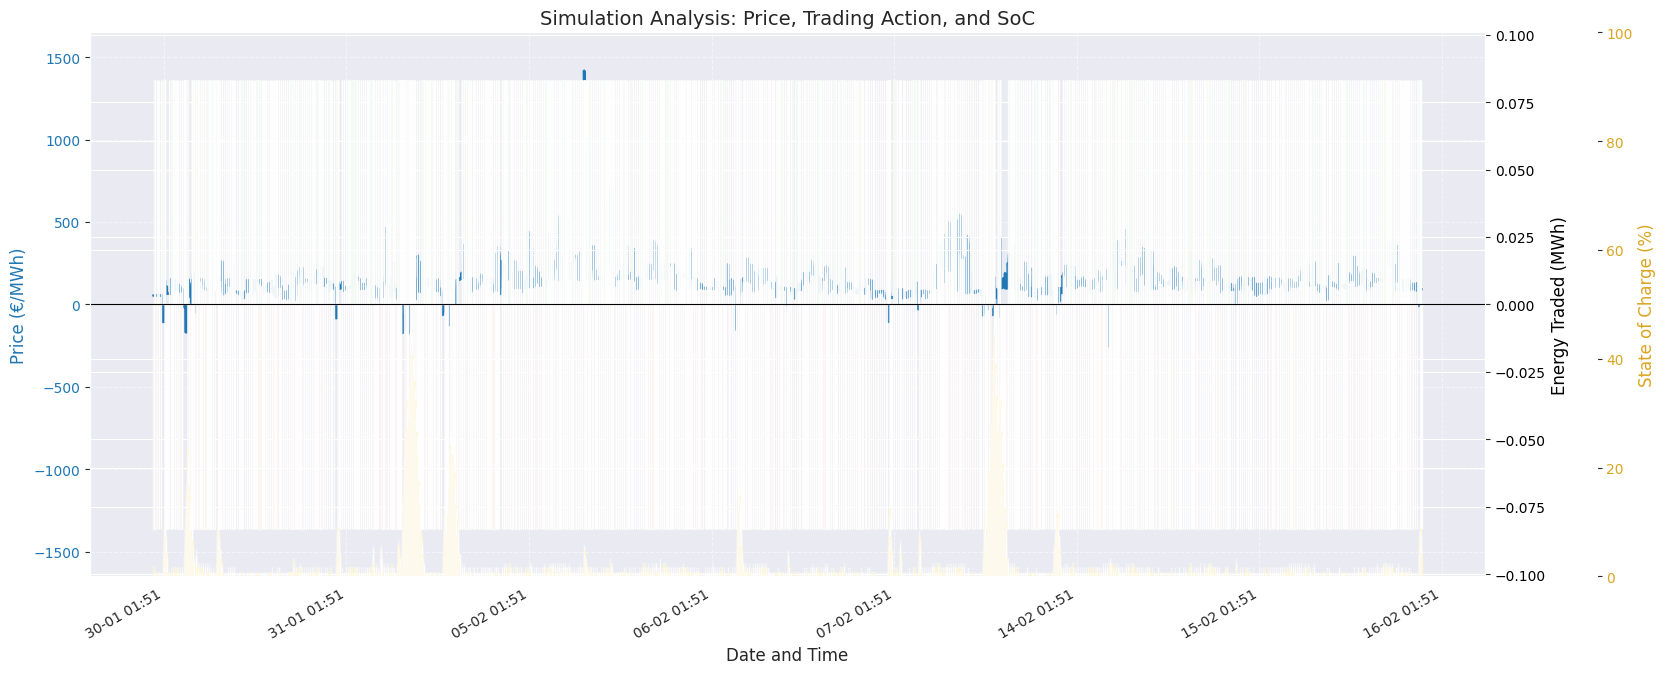

In [16]:

plot_simulation_results_minute_by_minute(history_df_dqn,
                                                   "iets",
                                                   10_000,
                                                   20_000)

Detected DQN architecture.


/home/lander/Documents/school/Thesis/ThesisGit/Simulation/suite_simple_trading/plotting.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  derived from the 'datetimes' key in the results.


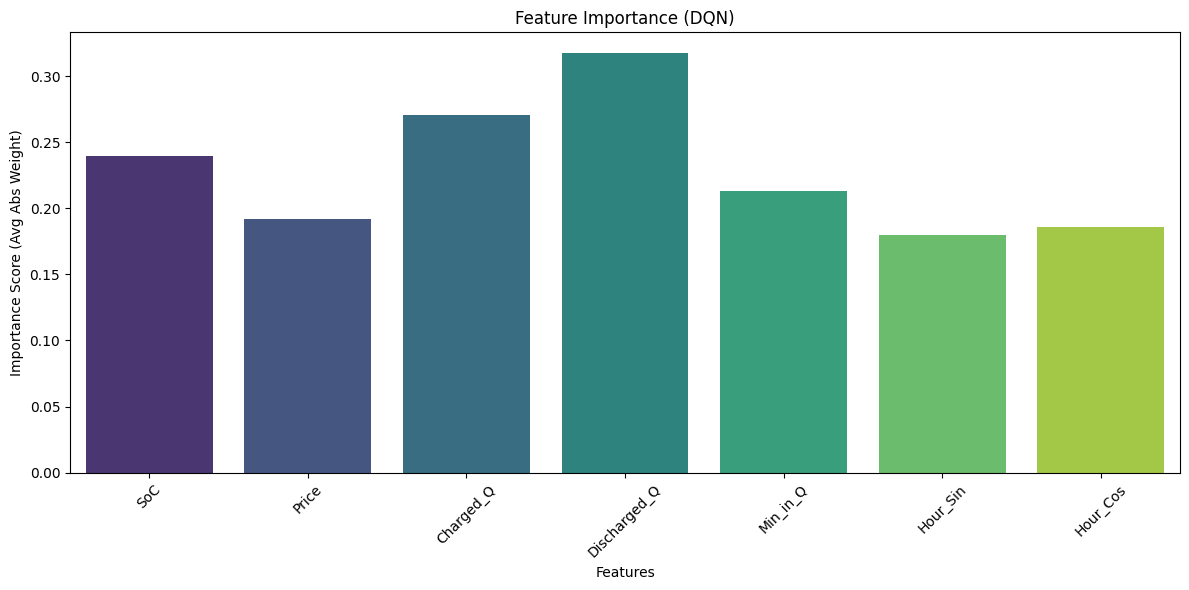

In [35]:
from Simulation.suite_simple_trading.plotting import plot_feature_importance

feature_names = [
    "SoC",
    "Price",
    "Charged_Q",
    "Discharged_Q",
    "Min_in_Q",
    "Hour_Sin", "Hour_Cos",
]
plot_feature_importance(dqn_agent_compare, feature_names)